In [1]:
import os
import sys

sys.path.append(os.path.join(os.path.dirname(__vsc_ipynb_file__), ".."))

import numpy as np
import numba
import matplotlib.pyplot as plt

from params import RestrepoParams
from cpu import *
from utils import luminal_buffer
#from sde import mean_reverting_gbm, levy_ou_process
import sympy

In [2]:
params = RestrepoParams(Ku=1.4e-4, h=2.5)

In [3]:
def beta_s(cs, params):
    calmodulin_buf = params.BCAM * params.KCAM / (cs + params.KCAM)**2
    SLH_buf = params.BSLH * params.KSLH / (cs + params.KSLH)**2
    return 1 / (1 + calmodulin_buf + SLH_buf)


def beta_j(cj, params):
    if isinstance(cj, np.ndarray):
        out = np.zeros_like(cj)
        for i, c in enumerate(cj):
            out[i] = luminal_buffer(c, params)
        return out
    else:
        return luminal_buffer(cj, params)

In [4]:
cs_range = np.linspace(0.0, 30.0, num=10000)
cj_range = np.linspace(200.0, 1400.0, num=10000)

In [5]:
ys = beta_s(cs_range, params)

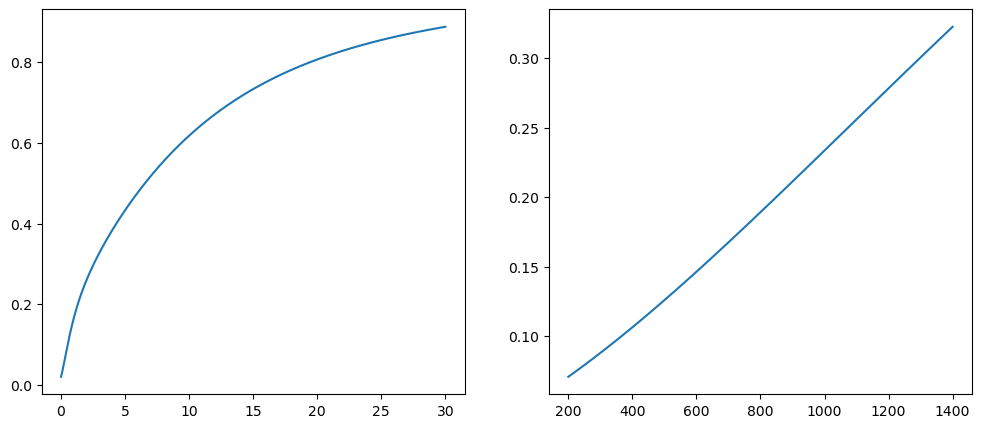

In [6]:
fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(cs_range, beta_s(cs_range, params))
ax[1].plot(cj_range, beta_j(cj_range, params))
plt.show()

In [7]:
a0_s = beta_s(0.2, params)
a1_s = (beta_s(0.21, params) - beta_s(0.2, params)) / (0.21 - 0.2)

a0_j = beta_j(1100, params)
a1_j = (beta_j(1100, params) - beta_j(1000, params)) / (1100 - 1000)

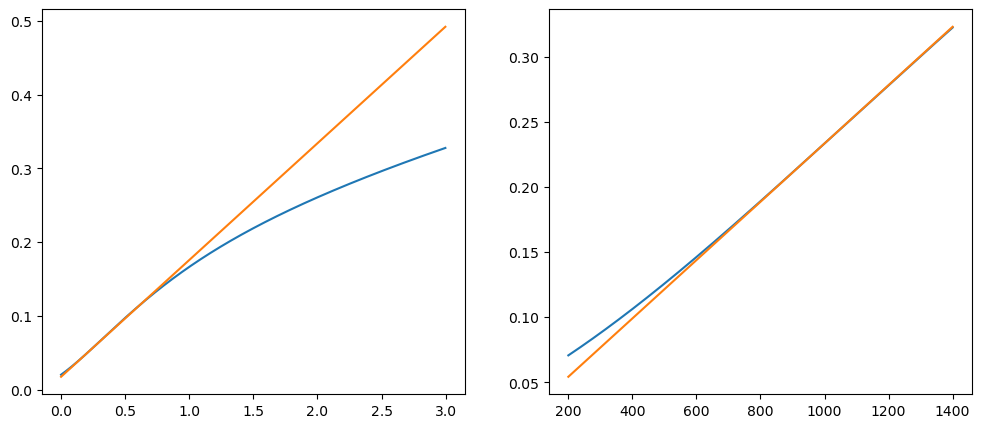

In [8]:
fig, ax = plt.subplots(1,2,figsize=(12,5))
ax[0].plot(cs_range[:1000], beta_s(cs_range[:1000], params))
ax[0].plot(cs_range[:1000], a0_s + a1_s * (cs_range[:1000] - 0.2))
ax[1].plot(cj_range, beta_j(cj_range, params))
ax[1].plot(cj_range, a0_j + a1_j * (cj_range - 1100))
plt.show()

Use linear approximations of $\beta_j$ and $\beta_s$ to make analysis easier. Will work well enough for $\beta_j$, but will not work as well for $\beta_s$ for large $c_s$. 

In [9]:
print("beta_s intercept:", a0_s - 0.2 * a1_s)
print("beta_s slope:", a1_s)
print("beta_j intercept:", a0_j - 1100 * a1_j)
print("beta_j slope:", a1_j)

beta_s intercept: 0.017546213007594125
beta_s slope: 0.15832296769770385
beta_j intercept: 0.009461374134047407
beta_j slope: 0.00022409334267494503


In [10]:
Po = sympy.symbols('P_o', Real=True)
cp, cj, cs, cn, ci, R1, CaTs = sympy.symbols('c_p c_j c_s c_n c_i R_1 CaT_s', Real=True)
Ku = sympy.symbols('K_u', Real=True)
Kb = sympy.symbols('K_b', Real=True)
kr = sympy.symbols('k_r', Real=True)
tau_p = sympy.symbols('tau_p', Real=True)
tau_s = sympy.symbols('tau_s', Real=True)
vp = sympy.symbols('v_p', Real=True)
vj = sympy.symbols('v_j', Real=True)
vs = sympy.symbols('v_s', Real=True)
kon = sympy.symbols('k_1', Real=True)
koff = sympy.symbols('k_2', Real=True)
B = sympy.symbols('B', Real=True)

In [106]:
params.KSLH

0.3

In [107]:
# linear approximations of buffers
beta_j_ = 0.00946 + 0.00022 * cj
beta_s_ = 1 / (1 + 7*24 / (7+cs)**2 + 13.4*0.3 / (0.3+cs)**2)

In [108]:
cp_ = (cs + kr * Po * cj) / (1 + kr *Po)

In [109]:
dcp_dPo = sympy.diff(cp_, Po).cancel().factor()
dcp2_dPo2 = sympy.diff(dcp_dPo, Po).cancel().factor()

In [110]:
dcp_dPo

k_r*(c_j - c_s)/(P_o*k_r + 1)**2

In [111]:
dcp2_dPo2

-2*k_r**2*(c_j - c_s)/(P_o*k_r + 1)**3

In [112]:
eps2 = sympy.nsimplify(0.1**2)

cp2 = cp**2
Po_subs = (cs - cp) / (kr*(cp - cj))
dcp_dPo_subs = dcp_dPo.subs({Po: Po_subs}).simplify()
dcp2_dPo2_subs = dcp2_dPo2.subs({Po: Po_subs}).simplify()
R4 = (1 - (R1 + Po_subs)).simplify()

In [113]:
dcp_dPo_subs

k_r*(c_j - c_p)**2/(c_j - c_s)

In [114]:
dcp2_dPo2_subs

-2*k_r**2*(c_j - c_p)**3/(c_j - c_s)**2

Create placeholders for $c_j - c_p$ and $c_j - c_s$ to help with simplification later

In [115]:
djp, djs, dsp, dnj, dsi = sympy.symbols('d_{jp} d_{js} d_{sp} d_{nj} d_{si}')

Po_ph = -dsp / (kr*djp)
dcp_dPo_ph = kr * djp**2 / djs
dcp2_dPo2_ph = -2*(kr**2) * djp**3 / djs**2
R4_ph = (1 - (R1 + Po_ph)).simplify()

In [116]:
Itr = dnj / 5 # using tau_tr = 5
Ir = ((kr / tau_p) * Po_ph * djs).simplify()
drift_cj = (beta_j_ * (Itr - (vp / vj) * Ir)).simplify() # No beta term here
#dcp_dcj = (kr * Po_ph / (1 + kr * Po_ph)).simplify()
dcp_dcj = -dsp / djs

In [117]:
Idps = -dsp / tau_p
Idsi = dsi / tau_s
ITcs = kon*cs*(B-CaTs) - koff*CaTs
drift_cs = (beta_s_ * ((vp/vs) * Idps - Idsi - ITcs)).simplify() # No beta term here
#dcp_dcs = (1 / (1 + kr * Po_ph)).simplify()
dcp_dcs = djp / djs

In [118]:
drift_Po = ((Ku*R1 + Kb*R4_ph)*cp2 - Po_ph).simplify() # using tau_c = 1
tr_hess_term = ((eps2 / 2) * dcp2_dPo2_ph * ((Ku*R1 + Kb*R4_ph)*cp2 + Po_ph)).simplify() # using tau_c = 1

In [119]:
drift_cp = sympy.simplify((
    dcp_dPo_ph * drift_Po +
    dcp_dcj * drift_cj +
    dcp_dcs * drift_cs +
    tr_hess_term)
    )

In [120]:
drift_cp

d_{jp}**2*k_r*(c_p**2*(K_b*(d_{jp}*k_r*(R_1 - 1) - d_{sp}) - K_u*R_1*d_{jp}*k_r) + d_{sp})/(100*d_{js}**2) + d_{jp}*(-c_p**2*(K_b*(d_{jp}*k_r*(R_1 - 1) - d_{sp}) - K_u*R_1*d_{jp}*k_r) + d_{sp})/d_{js} - d_{jp}*(-CaT_s*k_2 + c_s*k_1*(B - CaT_s) + d_{si}/tau_s + d_{sp}*v_p/(tau_p*v_s))/(d_{js}*(1 + 168/(c_s + 7)**2 + 4.02/(c_s + 0.3)**2)) - d_{sp}*(0.00022*c_j + 0.00946)*(d_{jp}*d_{nj}*tau_p*v_j + 5*d_{js}*d_{sp}*v_p)/(5*d_{jp}*d_{js}*tau_p*v_j)

In [121]:
# The sum of the square diffusion terms (i.e. the variance of the increments)
diff2_cp = (eps2 * (dcp_dPo_ph ** 2) * ((Ku*R1 + Kb*R4_ph)*cp2 + Po_ph)).simplify() # using tau_c = 1

In [122]:
diff2_cp

d_{jp}**3*k_r*(c_p**2*(K_b*(d_{jp}*k_r*(1 - R_1) + d_{sp}) + K_u*R_1*d_{jp}*k_r) - d_{sp})/(100*d_{js}**2)

In [123]:
params.Jmax * params.tau_ps / params.vp

0.25666666

In [124]:
drift_cp_subs = drift_cp.subs({Ku: 1.4e-4, Kb: 5e-5, tau_p: 0.022, tau_s: 0.1, vp: 0.00126, vs: 0.025, vj: 0.02, kon: 0.0327, koff: 0.0196, B: 70, kr: 0.2567})

In [125]:
diff2_subs = diff2_cp.subs({Ku: 1.4e-4, Kb: 5e-5, tau_p: 0.022, tau_s: 0.1, vp: 0.00126, vs: 0.025, vj: 0.02, kon: 0.0327, koff: 0.0196, B: 70, kr: 0.2567})

In [126]:
diff2_subs = diff2_subs.subs({djp: cj-cp, djs: cj-cs, dsp: cs-cp}).expand()

In [127]:
sympy.poly(diff2_subs, cp)

Poly((5.9305401e-8*R_1 + 1.61297445e-7)/(1.0*c_j**2 - 2.0*c_j*c_s + 1.0*c_s**2)*c_p**6 + (-2.37221604e-7*R_1*c_j - 5.1683978e-7*c_j - 1.2835e-7*c_s)/(1.0*c_j**2 - 2.0*c_j*c_s + 1.0*c_s**2)*c_p**5 + (3.55832406e-7*R_1*c_j**2 + 5.8273467e-7*c_j**2 + 3.8505e-7*c_j*c_s - 0.002567)/(1.0*c_j**2 - 2.0*c_j*c_s + 1.0*c_s**2)*c_p**4 + (-2.37221604e-7*R_1*c_j**3 - 2.6013978e-7*c_j**3 - 3.8505e-7*c_j**2*c_s + 0.007701*c_j + 0.002567*c_s)/(1.0*c_j**2 - 2.0*c_j*c_s + 1.0*c_s**2)*c_p**3 + (5.9305401e-8*R_1*c_j**4 + 3.2947445e-8*c_j**4 + 1.2835e-7*c_j**3*c_s - 0.007701*c_j**2 - 0.007701*c_j*c_s)/(1.0*c_j**2 - 2.0*c_j*c_s + 1.0*c_s**2)*c_p**2 + (0.002567*c_j**3 + 0.007701*c_j**2*c_s)/(1.0*c_j**2 - 2.0*c_j*c_s + 1.0*c_s**2)*c_p - 0.002567*c_j**3*c_s/(1.0*c_j**2 - 2.0*c_j*c_s + 1.0*c_s**2), c_p, domain='RR(R_1,c_j,c_s)')

In [128]:
drift_cp_subs_ = drift_cp_subs.subs({djp: cj-cp, djs: cj-cs, dsi: cs-ci, dsp: cs-cp, dnj: cn-cj})

In [129]:
CaTs_term = sympy.reduced(drift_cp_subs_, [CaTs])[0][0] * CaTs
cn_term = sympy.reduced(drift_cp_subs_, [cn])[0][0] * cn
ci_term = sympy.reduced(drift_cp_subs_, [ci])[0][0] * ci

In [176]:
mu_coeff0 = drift_cp_subs_.evalf(subs={cp:0.2})
mu_coeff1 = sympy.diff(drift_cp_subs_, cp).evalf(subs={cp:0.2})
mu_coeff2 = 0.5 * sympy.diff(sympy.diff(drift_cp_subs_, cp), cp).evalf(subs={cp:0.2})
mu_coeff3 =  sympy.diff(sympy.diff(sympy.diff(drift_cp_subs_, cp), cp), cp).evalf(subs={cp:0.2}) / 6

mu_order1 = mu_coeff0 + (cp - 0.2) * mu_coeff1
mu_order2 = mu_coeff0 + (cp - 0.2) * mu_coeff1 + mu_coeff2 * (cp - 0.2)**2
mu_order3 = mu_coeff0 + (cp - 0.2) * mu_coeff1 + mu_coeff2 * (cp - 0.2)**2 + mu_coeff3 * (cp-0.2)**3
mu_order3_modified = mu_coeff0 + (cp - 0.2) * mu_coeff1 + mu_coeff2 * (cp - 0.2)**2 + 0.85*mu_coeff3 * (cp-0.2)**3

In [191]:
evaluate_drift = sympy.lambdify((cp, cs, cj, R1, cn, ci, CaTs), drift_cp_subs_)

eval_mu_coeff_0 = sympy.lambdify((cs, cj, R1, cn, ci, CaTs), mu_coeff0)
eval_mu_coeff_1 = sympy.lambdify((cs, cj, R1, cn, ci, CaTs), mu_coeff1)
eval_mu_coeff_2 = sympy.lambdify((cs, cj, R1, cn, ci, CaTs), mu_coeff2)
eval_mu_coeff_3 = sympy.lambdify((cs, cj, R1, cn, ci, CaTs), mu_coeff3)


evaluate_drift_order1 = sympy.lambdify((cp, cs, cj, R1, cn, ci, CaTs), mu_order1)
evaluate_drift_order2 = sympy.lambdify((cp, cs, cj, R1, cn, ci, CaTs), mu_order2)
evaluate_drift_order3 = sympy.lambdify((cp, cs, cj, R1, cn, ci, CaTs), mu_order3)
evaluate_drift_order3_mod = sympy.lambdify((cp, cs, cj, R1, cn, ci, CaTs), mu_order3_modified)

In [315]:
cru = RestrepoCPU(params=params, ci=0.2, cs=0.2, cp=0.2, cnsr=1100, cjsr=1100)
cru.forward(1e-3, 5_000_000, collect_every=10, clamp=True)

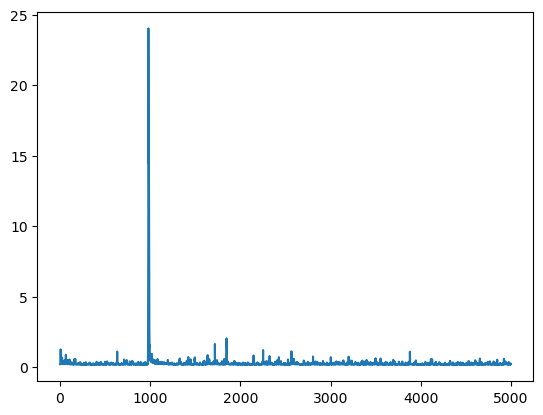

In [316]:
plt.plot(cru.t, cru.cs)
plt.show()

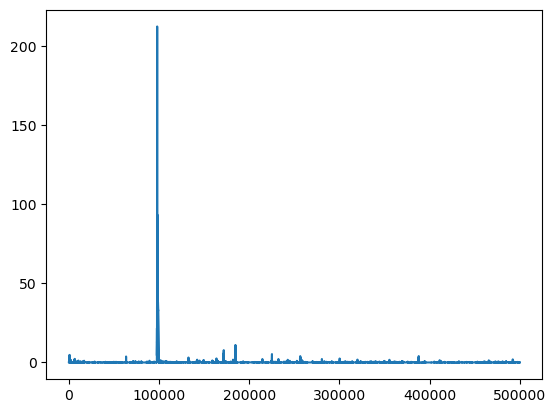

In [317]:
plt.plot(evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs) - evaluate_drift_order1(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs))
plt.show()

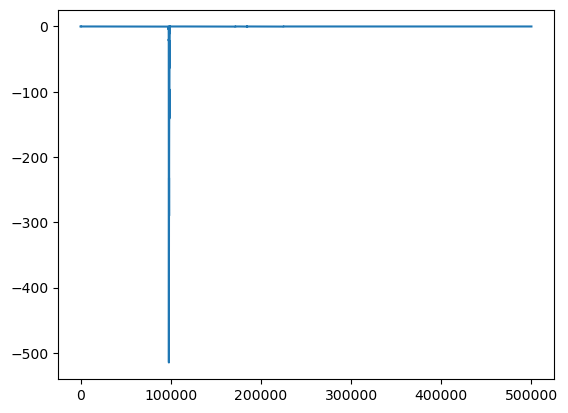

In [318]:
plt.plot(evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs) - evaluate_drift_order2(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs))
plt.show()

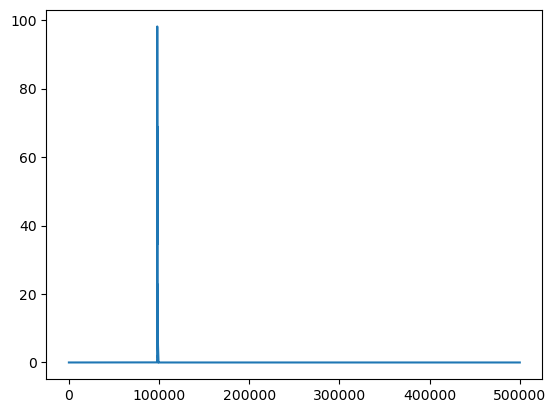

In [319]:
plt.plot(evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs) - evaluate_drift_order3(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs))
plt.show()

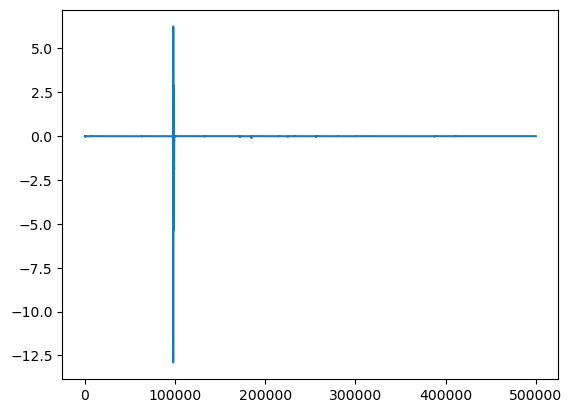

In [320]:
plt.plot(evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs) - evaluate_drift_order3_mod(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs))
plt.show()

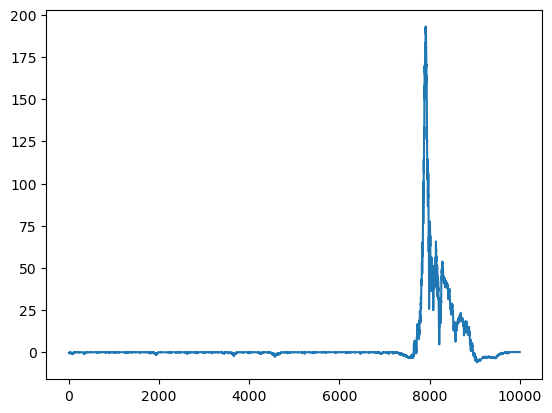

In [322]:
plt.plot(evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs)[90_000:100_000])
plt.show()

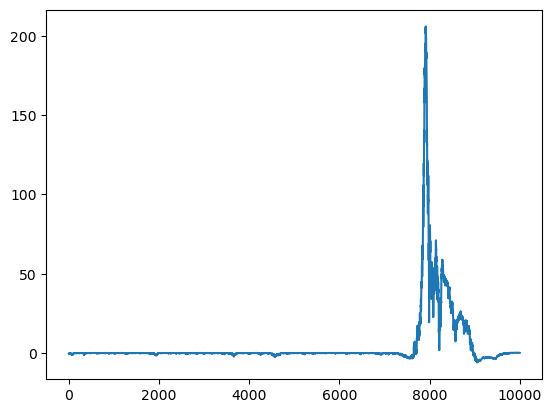

In [325]:
plt.plot(evaluate_drift_order3_mod(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs)[90_000:100_000])
plt.show()

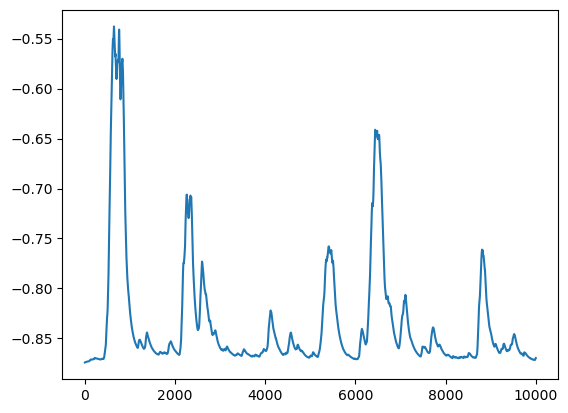

In [326]:
plt.plot(eval_mu_coeff_1(cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs)[:10_000])
plt.show()

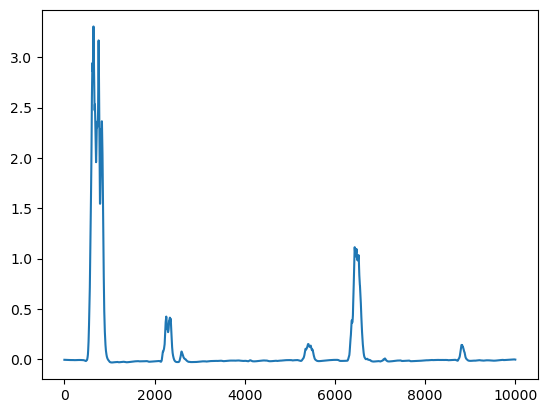

In [328]:
plt.plot(eval_mu_coeff_0(cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs)[:10_000] / eval_mu_coeff_1(cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs)[:10_000])
plt.show()

The linear terms appear to roughly independent of $R_1$

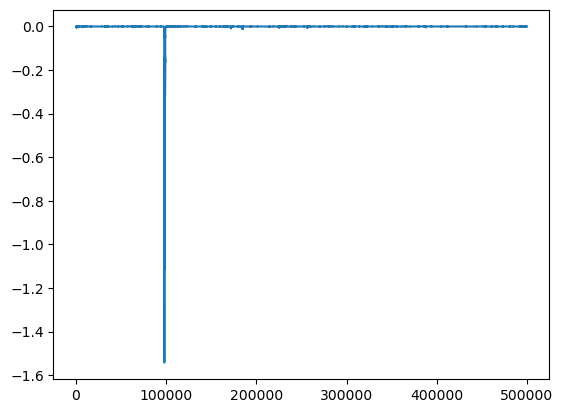

In [329]:
plt.plot(evaluate_drift_order1(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs) - evaluate_drift_order1(cru.cp, cru.cs, cru.cjsr, 1, cru.cnsr, cru.ci, cru.CaTs))
plt.show()

There also appears to be little harm in replacing $c_n$ with its initial value 1100. Other values of $c_n$ also work ok.

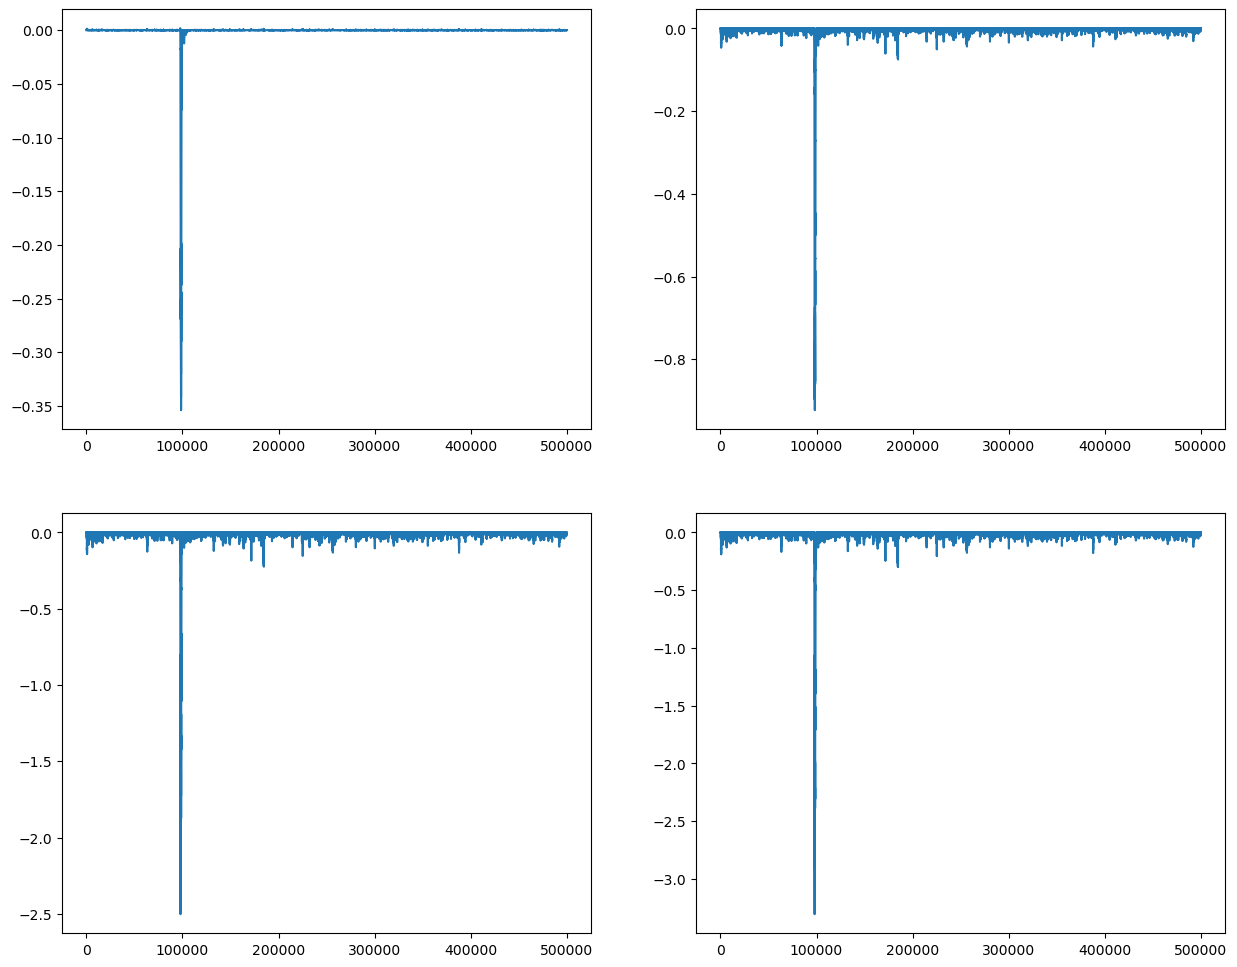

In [330]:
fig, ax = plt.subplots(2,2,figsize=(15,12))
ax[0,0].plot(evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs) - evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], 1100, cru.ci, cru.CaTs))
ax[0,1].plot(evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs) - evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], 1200, cru.ci, cru.CaTs))
ax[1,0].plot(evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs) - evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], 1400, cru.ci, cru.CaTs))
ax[1,1].plot(evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs) - evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], 1500, cru.ci, cru.CaTs))
plt.show()

In [334]:
cs_eq = (params.vp / (params.tau_ps * params.vs) * cru.cp + cru.ci / params.tau_si - params.koff * cru.CaTs + 0.2 * 2 * (1 / params.tau_sL_i + 1 / params.tau_sT_i)) / (params.vp / (params.tau_ps * params.vs) + 1 / params.tau_si + params.kon * (params.BT - cru.CaTs) + 2 * (1 / params.tau_sL_i + 1 / params.tau_sT_i))

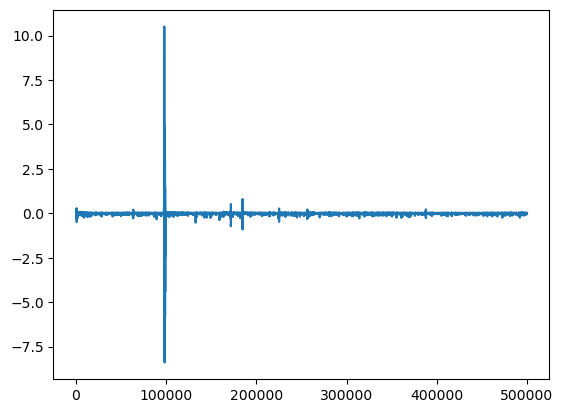

In [335]:
fig, ax = plt.subplots()
ax.plot(evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs) - evaluate_drift(cru.cp, cs_eq, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs))
plt.show()

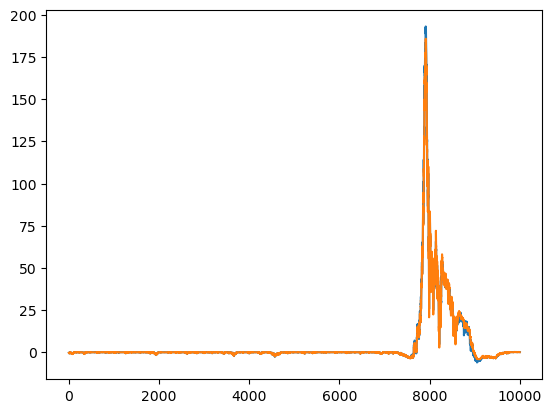

In [336]:
plt.plot(evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs)[90_000:100_000])
plt.plot(evaluate_drift(cru.cp, cs_eq, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs)[90_000:100_000])
plt.show()

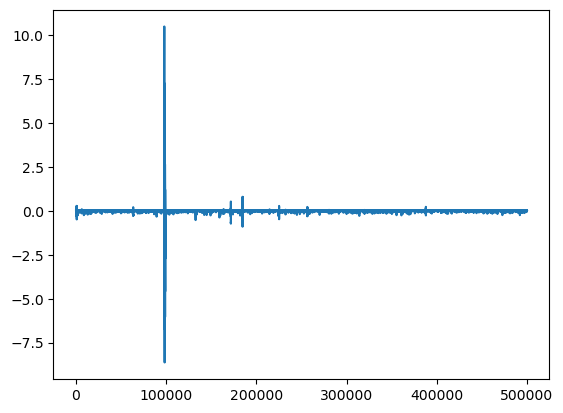

In [337]:
fig, ax = plt.subplots()
ax.plot(evaluate_drift(cru.cp, cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs) - evaluate_drift(cru.cp, cs_eq, cru.cjsr, cru.RyR[..., 0], 1100, cru.ci, cru.CaTs))
plt.show()

As seen above, replacing cs with it's equilibrium value appears to work reasonably well. This kills off the most problematic term in the drift and is therefore probably worth pursuing.

In [196]:
mu_0p0j = mu_coeff0.subs({cj:1100})
mu_0p1j = sympy.diff(mu_coeff0, cj).subs({cj:1100})
mu_0p2j = sympy.diff(sympy.diff(mu_coeff0, cj), cj).subs({cj:1100})

mu_0p_order1 = mu_0p0j + (cj - 1100) * mu_0p1j
mu_0p_order2 = mu_0p0j + mu_0p1j * (cj - 1100) + 0.5 * mu_0p2j * (cj - 1100)**2

eval_mu_0p0j = sympy.lambdify((cs, R1, cn, ci, CaTs), mu_0p0j)
evaluate_mu_0p1j = sympy.lambdify((cs, cj, R1, cn, ci, CaTs), mu_0p_order1)
evaluate_mu_0p2j = sympy.lambdify((cs, cj, R1, cn, ci, CaTs), mu_0p_order2)

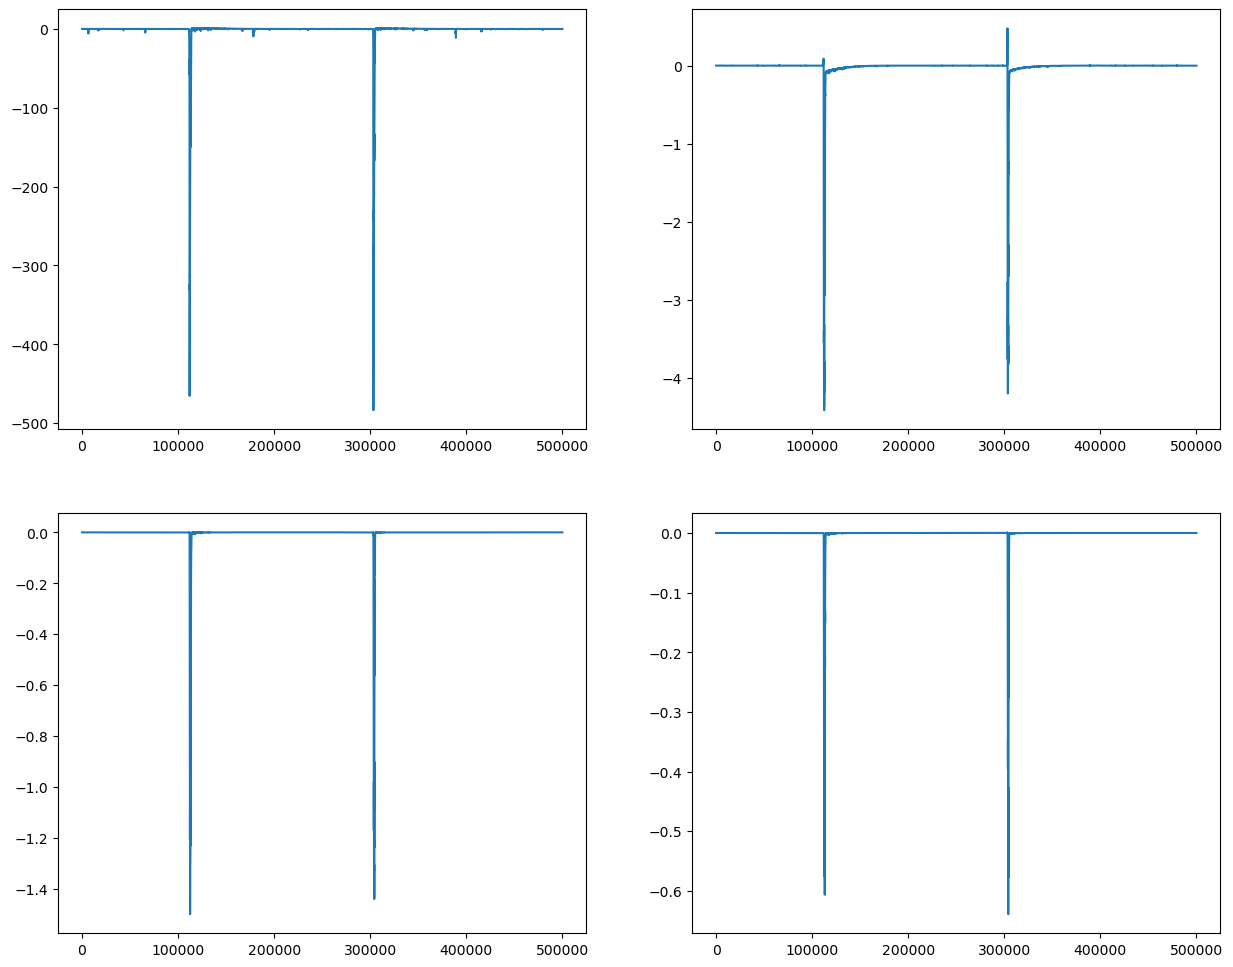

In [222]:
fig, ax = plt.subplots(2,2, figsize=(15,12))
x = eval_mu_coeff_0(cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs)
ax[0,0].plot(x)
ax[0,1].plot(x - eval_mu_0p0j(cru.cs, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs))
ax[1,0].plot(x - evaluate_mu_0p1j(cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs))
ax[1,1].plot(x - evaluate_mu_0p2j(cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs))

plt.show()

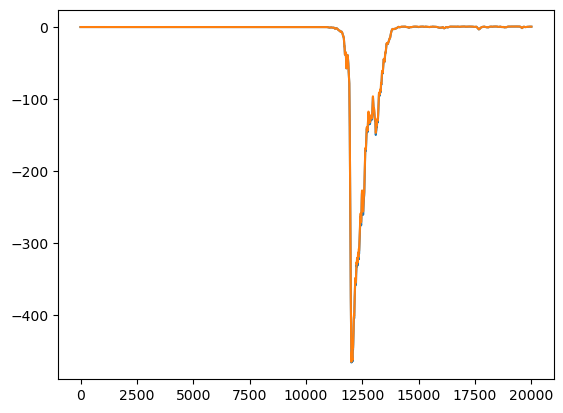

In [205]:
plt.plot(x[100_000:120_000])
plt.plot(eval_mu_0p0j(cru.cs, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs)[100_000:120_000])
plt.show()

Approximating the $c_j$ dependence of the constant term with $c_j = 1100$ appears to work quite well

In [210]:
mu_0p0j

-0.10392798690671*(c_s - 0.2)*(0.483912*c_n + 0.0063*(1100 - c_s)*(c_s - 0.2) - 532.3032)/(1100 - c_s) + 1099.8*(0.001016347176*R_1 + 1.000002*c_s - 0.19943576268)/(1100 - c_s) - 1099.8*(-0.0196*CaT_s - 10.0*c_i + 0.0327*c_s*(70.0 - CaT_s) + 12.2909090909091*c_s - 0.458181818181818)/((1100 - c_s)*(1.0 + 4.02/(c_s + 0.3)**2 + 3.42857142857143/(0.142857142857143*c_s + 1)**2)) + 3104.94062268*(-0.001016347176*R_1 + 0.999998*c_s - 0.20056423732)/(1100 - c_s)**2

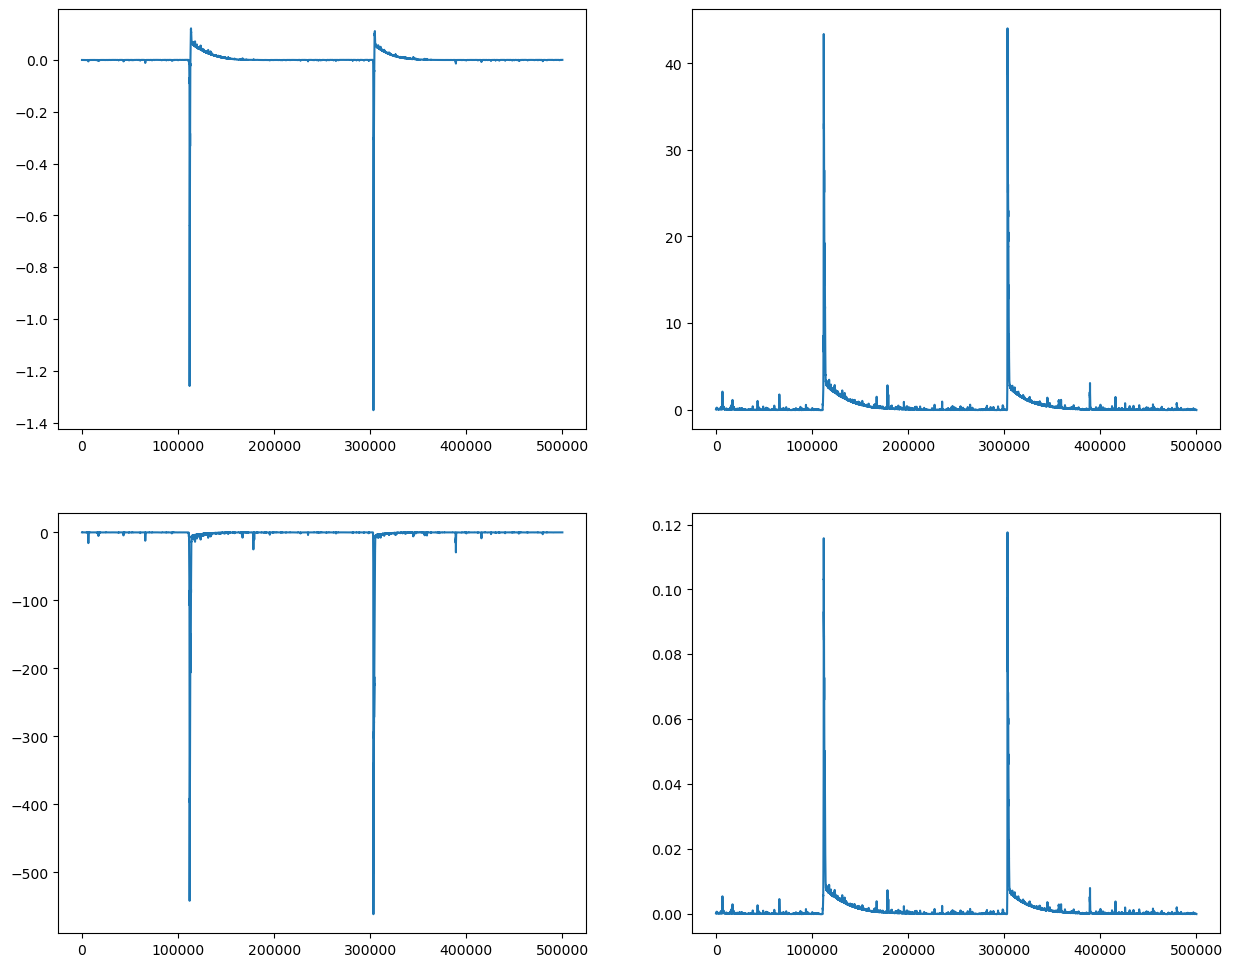

In [228]:
def term1(cs, cn):
    return -0.1*(cs-0.2)*(0.48*cn + 0.0063*(1100-cs)*(cs-0.2) - 532.3) / (1100 - cs)

def term2(cs, R1):
    return 1100 * (0.001 * R1 + cs - 0.2) / (1100 - cs)

def term3(cs, ci, CaTs):
    return -1100 * (-0.0196*CaTs - 10*ci + 0.0327*cs*(70-CaTs) + 12.29*cs - 0.458) / ((1100-cs)*(1+4.02/(cs+0.3)**2 + 3.42857 / (1.42857*cs + 1)**2))

def term4(cs, R1):
    return 3104.94*(-0.001*R1 + cs - 0.2) / (1100-cs)**2

fig, ax = plt.subplots(2,2, figsize=(15,12))
ax[0,0].plot(term1(cru.cs, cru.cnsr))
ax[0,1].plot(term2(cru.cs, cru.RyR[..., 0]))
ax[1,0].plot(term3(cru.cs, cru.ci, cru.CaTs))
ax[1,1].plot(term4(cru.cs, cru.RyR[..., 0]))

plt.show()

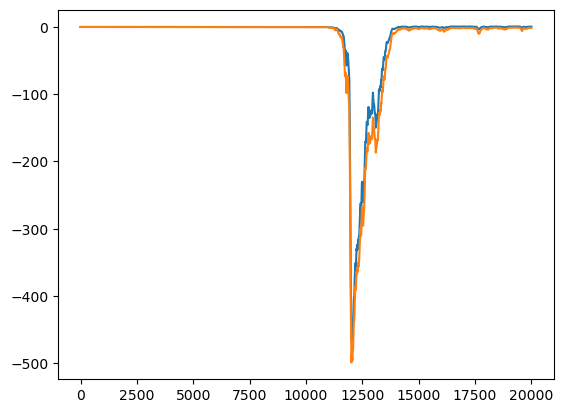

In [232]:
plt.plot(x[100_000:120_000])
plt.plot(term3(cru.cs, cru.ci, cru.CaTs)[100_000:120_000] + term2(cru.cs, 1)[100_000:120_000])
plt.show()

So just using the first two terms with $R_1=1$ seems to suffice.

In [233]:
mu_coeff1

0.002567*(0.4 - 2.0*c_j)*(-1.43752e-6*R_1*(c_j - 0.2) + 0.999998*c_s + 5.134e-7*(R_1 - 1.0)*(c_j - 0.2) - 0.1999996)/(c_j - c_s)**2 - 454.545454545455*(0.00022*c_j + 0.00946)*(c_s - 0.2)*(-0.00586*c_j - 0.00044*c_n + 0.0063*c_s)/((c_j - 0.2)*(c_j - c_s)) + 454.545454545455*(0.00022*c_j + 0.00946)*(0.00044*(-c_j + c_n)*(c_j - 0.2) + 0.0063*(c_j - c_s)*(c_s - 0.2))/((c_j - 0.2)*(c_j - c_s)) - 454.545454545455*(0.00022*c_j + 0.00946)*(c_s - 0.2)*(0.00044*(-c_j + c_n)*(c_j - 0.2) + 0.0063*(c_j - c_s)*(c_s - 0.2))/((c_j - 0.2)**2*(c_j - c_s)) + 0.002567*(c_j - 0.2)**2*(-1.43752e-5*R_1*(c_j - 0.2) + 9.2412e-7*R_1 - 2.0e-5*c_s + 5.134e-6*(R_1 - 1.0)*(c_j - 0.2) - 0.9999934866)/(c_j - c_s)**2 + (c_j - 0.2)*(1.43752e-5*R_1*(c_j - 0.2) - 9.2412e-7*R_1 + 2.0e-5*c_s - 5.134e-6*(R_1 - 1.0)*(c_j - 0.2) - 1.0000065134)/(c_j - c_s) + 2.29090909090909*(c_j - 0.2)/((c_j - c_s)*(1.0 + 4.02/(c_s + 0.3)**2 + 3.42857142857143/(0.142857142857143*c_s + 1)**2)) - (1.43752e-6*R_1*(c_j - 0.2) + 1.000002*c_s - 5.

In [234]:
mu_1p0j = mu_coeff1.subs({cj:1100})
mu_1p1j = sympy.diff(mu_coeff1, cj).subs({cj:1100})
mu_1p2j = sympy.diff(sympy.diff(mu_coeff1, cj), cj).subs({cj:1100})

mu_1p_order1 = mu_1p0j + (cj - 1100) * mu_1p1j
mu_1p_order2 = mu_1p0j + mu_1p1j * (cj - 1100) + 0.5 * mu_1p2j * (cj - 1100)**2

eval_mu_1p0j = sympy.lambdify((cs, R1, cn, ci, CaTs), mu_1p0j)
evaluate_mu_1p1j = sympy.lambdify((cs, cj, R1, cn, ci, CaTs), mu_1p_order1)
evaluate_mu_1p2j = sympy.lambdify((cs, cj, R1, cn, ci, CaTs), mu_1p_order2)

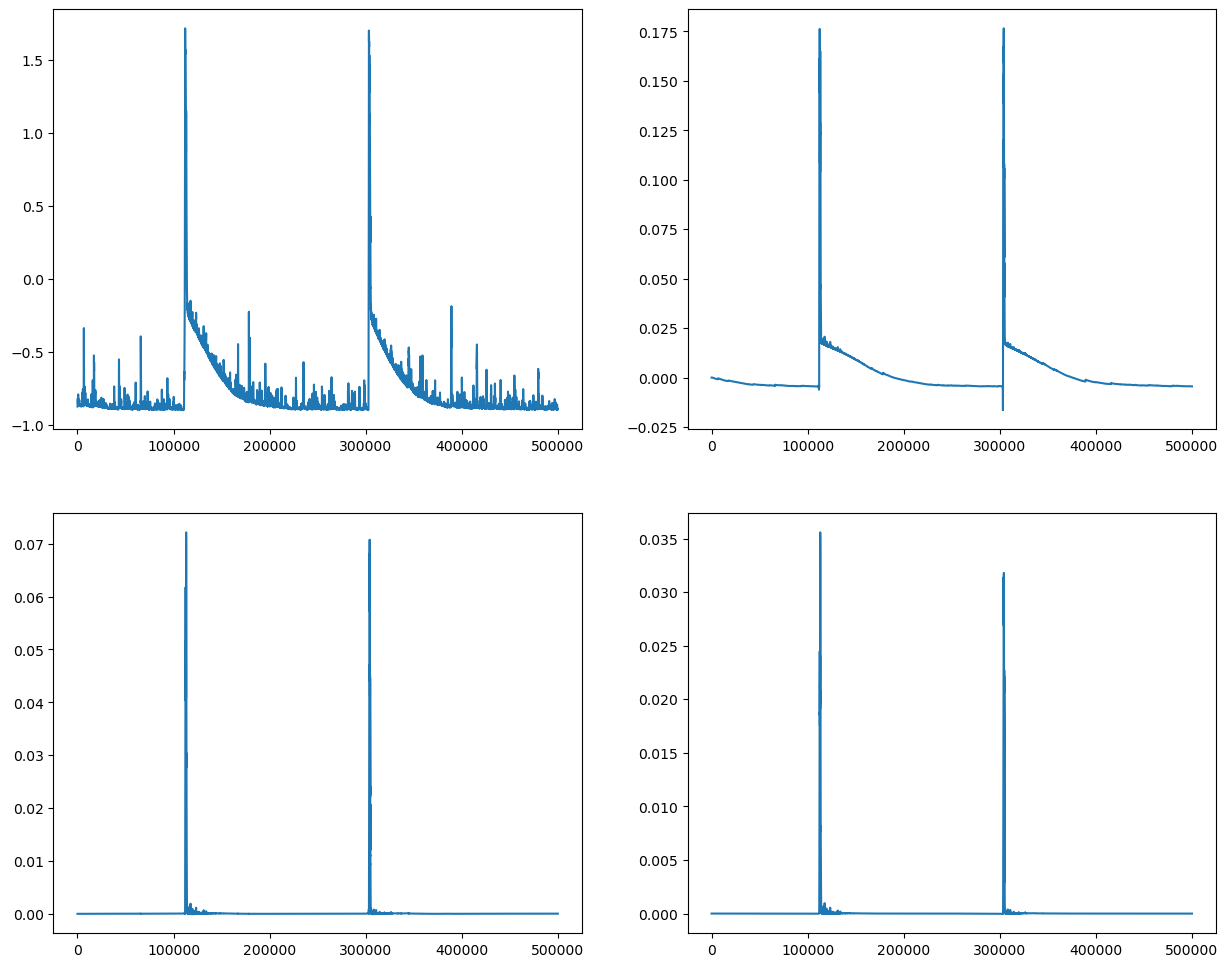

In [235]:
fig, ax = plt.subplots(2,2, figsize=(15,12))
x = eval_mu_coeff_1(cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs)
ax[0,0].plot(x)
ax[0,1].plot(x - eval_mu_1p0j(cru.cs, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs))
ax[1,0].plot(x - evaluate_mu_1p1j(cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs))
ax[1,1].plot(x - evaluate_mu_1p2j(cru.cs, cru.cjsr, cru.RyR[..., 0], cru.cnsr, cru.ci, cru.CaTs))

plt.show()

In [237]:
mu_1p1j

-(9.2412e-7*R_1 + 5.134e-7)/(1100 - c_s) + 1099.8*(9.2412e-6*R_1 + 5.134e-6)/(1100 - c_s) + 3.5715465600203e-6*(c_s - 0.2)*(-0.00044*c_n + 0.0063*c_s - 6.446)/(1100 - c_s) - 9.44971694005368e-5*(c_s - 0.2)*(0.00044*c_n + 0.0063*c_s - 0.969172)/(1100 - c_s) + 8.91695907988335e-8*(c_s - 0.2)*(0.483912*c_n + 0.0063*(1100 - c_s)*(c_s - 0.2) - 532.3032)/(1100 - c_s) + 0.000609018003273322*(c_s - 0.2)/(1100 - c_s) + (0.01016254764*R_1 + 2.0e-5*c_s - 0.9943601402)/(1100 - c_s) + 0.10392798690671*(0.00044*c_n + 0.0063*c_s - 0.969172)/(1100 - c_s) - 3.5715465600203e-6*(0.483912*c_n + 0.0063*(1100 - c_s)*(c_s - 0.2) - 532.3032)/(1100 - c_s) + 2.29090909090909/((1100 - c_s)*(1.0 + 4.02/(c_s + 0.3)**2 + 3.42857142857143/(0.142857142857143*c_s + 1)**2)) + 3104.94062268*(-9.2412e-6*R_1 - 5.134e-6)/(1100 - c_s)**2 - 5.6463732*(-9.2412e-7*R_1 - 5.134e-7)/(1100 - c_s)**2 + 0.10392798690671*(c_s - 0.2)*(-0.00044*c_n + 0.0063*c_s - 6.446)/(1100 - c_s)**2 + 9.44971694005368e-5*(c_s - 0.2)*(0.483912*c_n + 